In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
device = ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cuda device


In [4]:
# Mean and standard deviation values of CIFAR-100 dataset for normalization
mean = [0.5071, 0.4867, 0.4408]
std = [0.2675, 0.2565, 0.2761]

In [5]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [6]:
subset_target_classes = [
    # Flowers
    'orchid', 'poppy', 'sunflower',
    # Mammals
    'fox', 'raccoon', 'skunk',
    # Insects
    'butterfly', 'caterpillar', 'cockroach'
]

In [9]:
full_train_dataset = torchvision.datasets.CIFAR100(
    root='./data', 
    train=True, 
    download=True, 
    transform=train_transform)

full_val_dataset = torchvision.datasets.CIFAR100(
    root='./data', 
    train=False, 
    download=True, 
    transform=val_transform)

100%|██████████| 169M/169M [50:19<00:00, 56.0kB/s]   


In [12]:
# Map class names to their corresponding indices using the class_to_idx attribute of the dataset
train_class_ids = [full_train_dataset.class_to_idx[class_name] for class_name in subset_target_classes]
train_ids = [
    idx for idx, label in enumerate(full_train_dataset.targets) if label in train_class_ids
]
print(train_ids)
print(train_class_ids)

[12, 38, 51, 75, 82, 86, 89, 96, 120, 136, 141, 164, 167, 169, 174, 207, 221, 225, 233, 246, 264, 265, 266, 268, 274, 280, 314, 318, 324, 327, 329, 330, 333, 334, 336, 352, 362, 407, 413, 437, 439, 440, 444, 448, 456, 461, 466, 472, 481, 492, 498, 507, 510, 524, 582, 585, 591, 607, 621, 625, 627, 649, 659, 701, 712, 719, 724, 727, 737, 750, 777, 799, 800, 813, 833, 837, 838, 864, 866, 871, 875, 896, 897, 899, 902, 907, 911, 913, 938, 950, 952, 957, 959, 974, 976, 1000, 1005, 1029, 1038, 1043, 1045, 1076, 1077, 1086, 1087, 1089, 1102, 1103, 1104, 1110, 1125, 1133, 1136, 1143, 1144, 1155, 1178, 1191, 1197, 1221, 1231, 1242, 1261, 1272, 1273, 1278, 1292, 1295, 1296, 1348, 1359, 1369, 1379, 1394, 1397, 1402, 1428, 1447, 1450, 1454, 1458, 1469, 1472, 1496, 1499, 1504, 1506, 1524, 1550, 1577, 1581, 1589, 1597, 1601, 1625, 1642, 1647, 1651, 1656, 1660, 1695, 1717, 1718, 1730, 1754, 1758, 1836, 1854, 1859, 1863, 1888, 1889, 1894, 1900, 1913, 1919, 1921, 1930, 1931, 1935, 1938, 1948, 1951, 1959

In [13]:
val_class_ids = [full_val_dataset.class_to_idx[class_name] for class_name in subset_target_classes]
val_ids = [
    idx for idx, label in enumerate(full_val_dataset.targets) if label in val_class_ids
]
print(val_ids)
print(val_class_ids)


[7, 11, 22, 41, 48, 67, 70, 76, 82, 91, 97, 144, 152, 155, 158, 166, 178, 191, 195, 225, 233, 238, 241, 242, 269, 275, 277, 279, 285, 286, 308, 311, 333, 338, 343, 345, 351, 357, 359, 415, 432, 453, 464, 472, 473, 481, 514, 519, 524, 529, 547, 556, 582, 595, 606, 611, 629, 630, 645, 651, 663, 665, 669, 680, 681, 694, 714, 727, 728, 749, 768, 773, 788, 789, 825, 826, 831, 845, 858, 868, 875, 878, 891, 893, 928, 938, 941, 942, 947, 959, 969, 973, 976, 979, 986, 1092, 1097, 1106, 1115, 1122, 1133, 1157, 1167, 1177, 1190, 1209, 1227, 1231, 1244, 1255, 1281, 1309, 1313, 1320, 1368, 1400, 1403, 1425, 1432, 1442, 1447, 1456, 1467, 1473, 1498, 1505, 1523, 1526, 1533, 1536, 1542, 1612, 1630, 1645, 1648, 1698, 1699, 1702, 1713, 1726, 1742, 1755, 1764, 1767, 1781, 1783, 1799, 1811, 1818, 1892, 1916, 1917, 1939, 1964, 1965, 1967, 1993, 2038, 2042, 2073, 2079, 2131, 2137, 2143, 2158, 2163, 2168, 2192, 2205, 2210, 2216, 2234, 2243, 2265, 2268, 2272, 2274, 2309, 2313, 2336, 2349, 2356, 2359, 2364, 24

In [14]:
print(f"Number of training samples: {len(train_ids)}")
print(f"Number of validation samples: {len(val_ids)}")

Number of training samples: 4500
Number of validation samples: 900


In [16]:
subset_train_dataset = Subset(full_train_dataset, train_ids)
subset_val_dataset = Subset(full_val_dataset, val_ids)

In [18]:
# Remap the labels in the subset datasets to be in the range [0, 8]
class LabelRemapDataset(Dataset):
    def __init__(self, subset_dataset, class_ids):
        self.subset_dataset = subset_dataset
        self.class_ids = class_ids
        self.label_map = {class_id: new_label for new_label, class_id in enumerate(class_ids)}

    def __len__(self):
        return len(self.subset_dataset)

    def __getitem__(self, idx):
        image, label = self.subset_dataset[idx]
        remapped_label = self.label_map[label]
        return image, remapped_label

In [19]:
train_dataset = LabelRemapDataset(subset_train_dataset, train_class_ids)
val_dataset = LabelRemapDataset(subset_val_dataset, val_class_ids)

In [20]:
train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=64, 
    shuffle=True
    )

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=64, 
    shuffle=False
    )



In [21]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        # First Convolution
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second Convolution
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third Convolution
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()

        # Fully Connected Layer 
        self.fc1 = nn.Linear(128*4*4, 512)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Pass input through the first convolutional block
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # Pass feature maps through the second convolutional block
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        # Pass feature maps through the third convolutional block
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        # Flatten the output for the fully connected layers
        x = self.flatten(x)

        # Pass the flattened features through the fully connected layers
        x = self.fc1(x)
        x = self.relu4(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [25]:
num_classes = len(subset_target_classes)
print(num_classes)

9


In [26]:
model = SimpleCNN(num_classes=num_classes)

In [27]:
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=9, bias=True)
)


In [28]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [31]:
def training_loop(model, train_loader, val_loader, loss_function, optimizer, num_epochs, device):

    # transfer model to device
    model = model.to(device)

    # List to store training and validation metrics
    train_loss = []
    val_loss = []
    val_accuracy = []

    print("----Training Started----")

    for epoch in range(num_epochs):
        # Set the model to training mode
        model.train()

        # Initilize running loss for the current epoch
        running_loss = 0.0

        for image, label in train_loader:
            # Move input and target to device
            image, label = image.to(device), label.to(device)
            # Clear the gradients
            optimizer.zero_grad()
            # Forward Pass
            pred_output = model(image)
            # Compute the loss
            loss = loss_function(pred_output, label)
            # Compute the gradients
            loss.backward()
            # Update the parameters
            optimizer.step()

            # Accumulate training loss for the batch
            running_loss += loss.item()*image.size(0) # Loss per channels

        # Calculate epoch loss
        epoch_loss = running_loss / len(train_loader.dataset)

        train_loss.append(epoch_loss)

        # Set the model in evalution mode
        model.eval()
        running_val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for image, label in val_loader:
                image, label = image.to(device), label.to(device)
                # Forward Pass
                pred_out = model(image)
                # Compute the loss
                loss = loss_function(pred_out, label)
                # Accumulate running loss for the batch
                running_val_loss += loss.item()*image.size(0)

                # Get the predicted class label
                _, predicted = torch.max(pred_out, 1)
                total += label.size(0)
                correct += (predicted == label).sum().item()

        epoch_val_loss = running_val_loss / len(val_loader.dataset)

        val_loss.append(epoch_val_loss)

        # Calculate validation accuracies
        epoch_accuracy = 100*correct/total
        val_accuracy.append(epoch_accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {epoch_accuracy:.2f}%")

    print("----Training Completed----")

    metrics = [train_loss, val_loss, val_accuracy]

    return model, metrics



In [32]:
num_epochs = 15
trained_model, trained_metrics = training_loop(
    model=model, 
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    num_epochs=num_epochs,
    device=device
)

----Training Started----
Epoch [1/15], Train Loss: 1.2187, Val Loss: 1.0104, Val Accuracy: 64.11%
Epoch [2/15], Train Loss: 1.0683, Val Loss: 0.9745, Val Accuracy: 67.22%
Epoch [3/15], Train Loss: 0.9430, Val Loss: 0.9183, Val Accuracy: 70.44%
Epoch [4/15], Train Loss: 0.8777, Val Loss: 0.8404, Val Accuracy: 71.22%
Epoch [5/15], Train Loss: 0.8386, Val Loss: 0.7632, Val Accuracy: 73.00%
Epoch [6/15], Train Loss: 0.7659, Val Loss: 0.7452, Val Accuracy: 74.44%
Epoch [7/15], Train Loss: 0.7154, Val Loss: 0.8231, Val Accuracy: 72.78%
Epoch [8/15], Train Loss: 0.6788, Val Loss: 0.7341, Val Accuracy: 76.22%
Epoch [9/15], Train Loss: 0.6312, Val Loss: 0.6995, Val Accuracy: 76.89%
Epoch [10/15], Train Loss: 0.5875, Val Loss: 0.6974, Val Accuracy: 78.44%
Epoch [11/15], Train Loss: 0.5522, Val Loss: 0.7197, Val Accuracy: 77.33%
Epoch [12/15], Train Loss: 0.5270, Val Loss: 0.6797, Val Accuracy: 76.89%
Epoch [13/15], Train Loss: 0.4843, Val Loss: 0.6665, Val Accuracy: 77.44%
Epoch [14/15], Train L

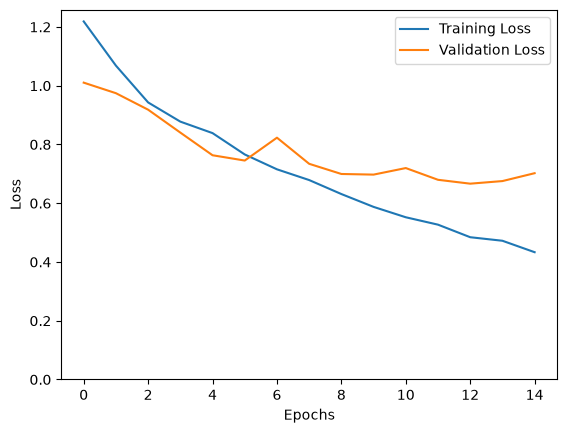

In [42]:
epoch = range(num_epochs)
train_loss = trained_metrics[0]
val_loss = trained_metrics[1]
val_accuracy = trained_metrics[2]

plt.plot(epoch, train_loss, label="Training Loss")
plt.plot(epoch, val_loss, label="Validation Loss")
plt.ylim(0)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()